##  Regresión Multivariada 
### Selección de variables predictoras

Dr. Hugo García Tecocoatzi

In [1]:
#  Importar bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.feature_selection import f_regression, SelectKBest

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline

Vamos a generar datos sintéticos para la actividad:

In [35]:

#  Simulamos un problema de bienes raíces
np.random.seed(42)
n = 200

# Variables predictoras
Tamaño = np.random.randn(n) * 10 + 50           # Tamaño en m²
Habitaciones = Tamaño + np.random.randn(n) * 3  # Número de habitaciones (correlacionado)
Antigüedad = np.random.randn(n) * 5 + 20        # Antigüedad en años
Ubicación = np.random.randn(n) * 3 + 5          # Calidad de ubicación (1-10)

# Variable respuesta (precio)
Precio = 500 + 25*Tamaño + 15*Habitaciones - 8*Antigüedad + 30*Ubicación + np.random.randn(n)*50

# Crear DataFrame
df = pd.DataFrame({
    'Tamaño': Tamaño,
    'Habitaciones': Habitaciones,
    'Antigüedad': Antigüedad,
    'Ubicación': Ubicación,
    'Precio': Precio
})

data = pd.read_csv("Data/Realestate.csv")
data = data.drop("No", axis  = 1)
print(f"Forma del dataset: {data.shape}")
print("\nPrimeras 5 filas:")
data.head()
data = data.rename(columns = {'X3 distance to the nearest MRT station': "Distance", 'X1 transaction date': 'Date', 'X2 house age' : 'Age', 'X5 latitude': 'Latitude', 'X6 longitude': 'Longitude', 'Y house price of unit area' : 'Price', 'X4 number of convenience stores' : 'Number'})
data = data.drop("Date", axis = 1)

Forma del dataset: (414, 7)

Primeras 5 filas:


In [32]:
# Estadísticas descriptivas
print("ESTADÍSTICAS DESCRIPTIVAS\n")
print(data.describe().round(2))

ESTADÍSTICAS DESCRIPTIVAS

          Date     Age  Distance  Number  Latitude  Longitude   Price
count   414.00  414.00    414.00  414.00    414.00     414.00  414.00
mean   2013.15   17.71   1083.89    4.09     24.97     121.53   37.98
std       0.28   11.39   1262.11    2.95      0.01       0.02   13.61
min    2012.67    0.00     23.38    0.00     24.93     121.47    7.60
25%    2012.92    9.02    289.32    1.00     24.96     121.53   27.70
50%    2013.17   16.10    492.23    4.00     24.97     121.54   38.45
75%    2013.42   28.15   1454.28    6.00     24.98     121.54   46.60
max    2013.58   43.80   6488.02   10.00     25.01     121.57  117.50



MATRIZ DE CORRELACIÓN

             Age  Distance  Number  Latitude  Longitude  Price
Age        1.000     0.026   0.050     0.054     -0.049 -0.211
Distance   0.026     1.000  -0.603    -0.591     -0.806 -0.674
Number     0.050    -0.603   1.000     0.444      0.449  0.571
Latitude   0.054    -0.591   0.444     1.000      0.413  0.546
Longitude -0.049    -0.806   0.449     0.413      1.000  0.523
Price     -0.211    -0.674   0.571     0.546      0.523  1.000


<Axes: >

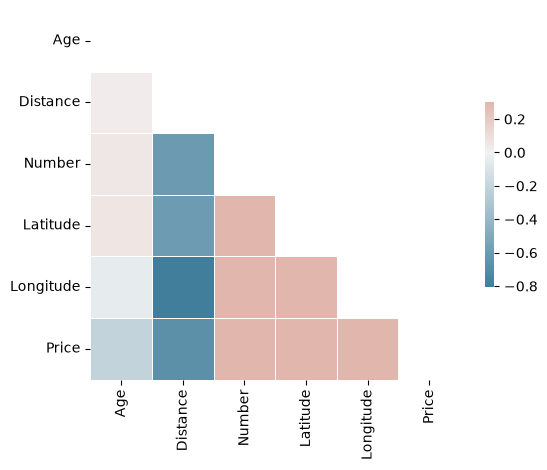

In [36]:
# Matriz de correlación detallada
print("\nMATRIZ DE CORRELACIÓN\n")
print(data.corr().round(3))
mask = np.triu(np.ones_like(data.corr(), dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(data.corr(), mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

### Preguntas

1. ¿Qué variables tienen mayor correlación con el Precio?
    - Tamaño y habitaciones
2. ¿Hay variables altamente correlacionadas entre sí? ¿Cuáles?
    - Las habitaciones y el tamaño, precio y tamaño, y precio y habitaciones
3. ¿Cómo crees que afecta cada variable al precio?"
    - 

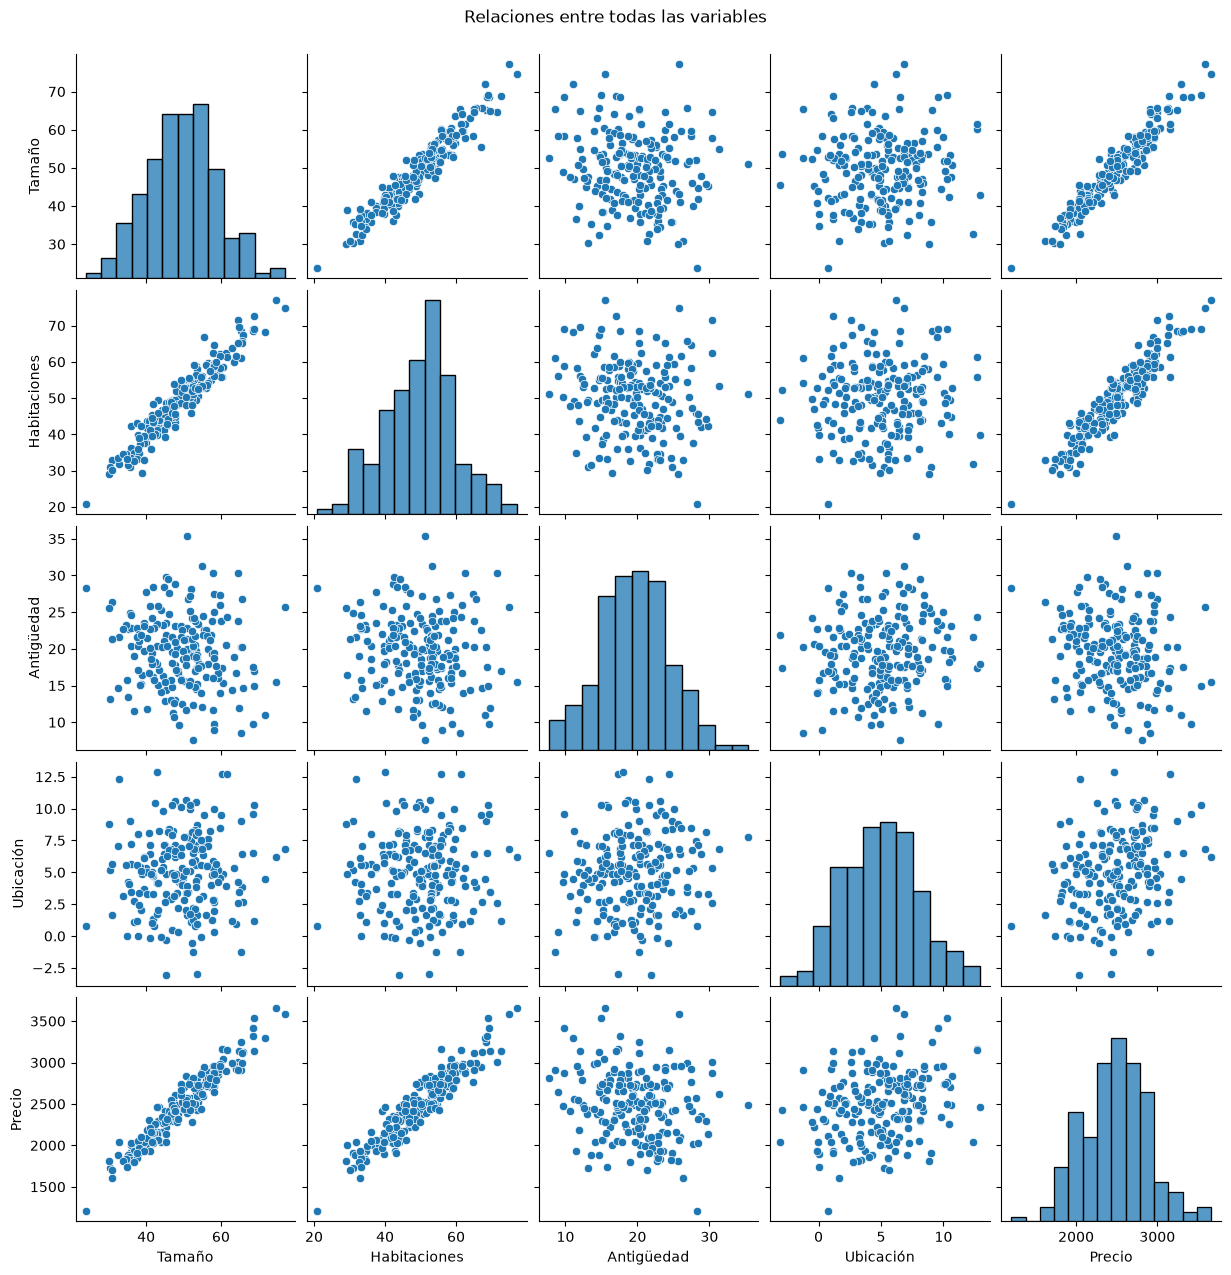

In [5]:
# Pairplot de variables
sns.pairplot(df)
plt.suptitle('Relaciones entre todas las variables', y=1.02)
plt.show()

In [6]:
#  Dividir datos en entrenamiento y prueba
X = df.drop('Precio', axis=1)
y = df['Precio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño de prueba: {X_test.shape[0]} muestras")

Tamaño de entrenamiento: 140 muestras
Tamaño de prueba: 60 muestras


In [7]:
# Entrenar modelo de regresión lineal con todas las variables
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Mostrar coeficientes
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
})
print("=== COEFICIENTES DEL MODELO ===\n")
print(coeficientes)
print(f"\nIntercept (término constante): {modelo.intercept_:.4f}")

=== COEFICIENTES DEL MODELO ===

       Variable  Coeficiente
0        Tamaño    28.191932
1  Habitaciones    12.110154
2    Antigüedad    -7.294327
3     Ubicación    32.566862

Intercept (término constante): 467.3919


In [8]:
# Evaluar modelo completo
y_pred = modelo.predict(X_test)

MAE = metrics.mean_absolute_error(y_test, y_pred)
MSE = metrics.mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = metrics.r2_score(y_test, y_pred)

print("=== MÉTRICAS DE EVALUACIÓN ===\n")
print(f"Error Absoluto Medio (MAE): {MAE:.4f}")
print(f"Error Cuadrático Medio (MSE): {MSE:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {RMSE:.4f}")
print(f"R² (Coeficiente de Determinación): {R2:.4f}")

=== MÉTRICAS DE EVALUACIÓN ===

Error Absoluto Medio (MAE): 39.1850
Error Cuadrático Medio (MSE): 2274.3596
Raíz del Error Cuadrático Medio (RMSE): 47.6902
R² (Coeficiente de Determinación): 0.9828


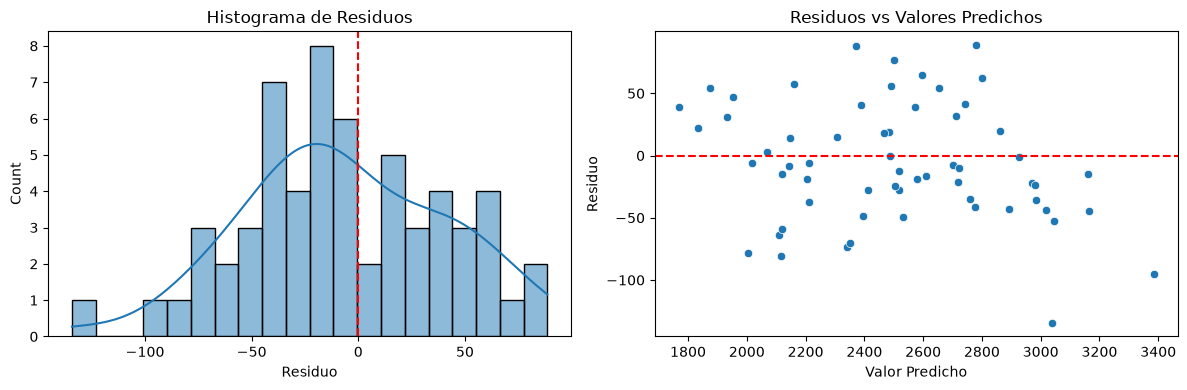

Media de residuos: -6.4355
Desviación estándar de residuos: 47.6528


In [9]:
# Análisis de residuos
residuos = y_test - y_pred

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(residuos, kde=True, bins=20)
plt.axvline(x=0, color='r', linestyle='--')
plt.title('Histograma de Residuos')
plt.xlabel('Residuo')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs Valores Predichos')
plt.xlabel('Valor Predicho')
plt.ylabel('Residuo')

plt.tight_layout()
plt.show()

print(f"Media de residuos: {residuos.mean():.4f}")
print(f"Desviación estándar de residuos: {residuos.std():.4f}")

In [10]:
# Cálculo del VIF (Factor de Inflación de la Varianza)
X_constant = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_constant.columns
vif_data["VIF"] = [variance_inflation_factor(X_constant.values, i) 
                   for i in range(X_constant.shape[1])]

print("=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===\n")
print(vif_data)
print("\n Recuerda:")
print("- VIF > 5: indica alta multicolinealidad")
print("- VIF > 10: indica multicolinealidad severa")

=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===

       Variable        VIF
0         const   1.000000
1        Tamaño  11.780300
2  Habitaciones  11.727624
3    Antigüedad   1.032297
4     Ubicación   1.029735

 Recuerda:
- VIF > 5: indica alta multicolinealidad
- VIF > 10: indica multicolinealidad severa


In [11]:
#  Selección hacia adelante (Forward Selection)
def forward_selection(X, y, threshold=0.05):
    """
    Selección de variables hacia adelante basada en p-valor
    """
    included = []
    while True:
        changed = False
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)
        
        for new_col in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_col]]))).fit()
            new_pval[new_col] = model.pvalues[new_col]
        
        best_pval = new_pval.min()
        if best_pval < threshold:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
        
        if not changed:
            break
    
    return included

print("=== SELECCIÓN HACIA ADELANTE ===\n")
variables_seleccionadas = forward_selection(X, y)
print(f"Variables seleccionadas: {variables_seleccionadas}")

=== SELECCIÓN HACIA ADELANTE ===

Variables seleccionadas: ['Tamaño', 'Ubicación', 'Antigüedad', 'Habitaciones']


In [12]:
# Comparación de modelos con diferentes variables
print("=== COMPARACIÓN DE MODELOS ===\n")

combinaciones = [
    ['Tamaño'],
    ['Tamaño', 'Habitaciones'],
    ['Tamaño', 'Habitaciones', 'Antigüedad'],
    ['Tamaño', 'Habitaciones', 'Antigüedad', 'Ubicación'],
    variables_seleccionadas
]

nombres_combinaciones = [
    'Modelo 1: Tamaño',
    'Modelo 2: Tamaño + Habitaciones',
    'Modelo 3: Tamaño + Habitaciones + Antigüedad',
    'Modelo 4: Modelo completo',
    'Modelo 5: Variables seleccionadas (Forward)'
]

for nombre, vars_list in zip(nombres_combinaciones, combinaciones):
    X_sel = sm.add_constant(X[vars_list])
    model = sm.OLS(y, X_sel).fit()
    
    print(f"📊 {nombre}")
    print(f"  Variables: {vars_list}")
    print(f"  R² = {model.rsquared:.4f}")
    print(f"  R² ajustado = {model.rsquared_adj:.4f}")
    print(f"  AIC = {model.aic:.2f}")
    print(f"  BIC = {model.bic:.2f}")
    print()

=== COMPARACIÓN DE MODELOS ===

📊 Modelo 1: Tamaño
  Variables: ['Tamaño']
  R² = 0.9178
  R² ajustado = 0.9174
  AIC = 2470.82
  BIC = 2477.41

📊 Modelo 2: Tamaño + Habitaciones
  Variables: ['Tamaño', 'Habitaciones']
  R² = 0.9228
  R² ajustado = 0.9220
  AIC = 2460.37
  BIC = 2470.26

📊 Modelo 3: Tamaño + Habitaciones + Antigüedad
  Variables: ['Tamaño', 'Habitaciones', 'Antigüedad']
  R² = 0.9276
  R² ajustado = 0.9265
  AIC = 2449.43
  BIC = 2462.63

📊 Modelo 4: Modelo completo
  Variables: ['Tamaño', 'Habitaciones', 'Antigüedad', 'Ubicación']
  R² = 0.9866
  R² ajustado = 0.9863
  AIC = 2113.96
  BIC = 2130.45

📊 Modelo 5: Variables seleccionadas (Forward)
  Variables: ['Tamaño', 'Ubicación', 'Antigüedad', 'Habitaciones']
  R² = 0.9866
  R² ajustado = 0.9863
  AIC = 2113.96
  BIC = 2130.45



In [13]:
# Análisis detallado del mejor modelo
print("=== MEJOR MODELO SEGÚN FORWARD SELECTION ===\n")

X_sel = sm.add_constant(X[variables_seleccionadas])
modelo_final = sm.OLS(y, X_sel).fit()
print(modelo_final.summary())

=== MEJOR MODELO SEGÚN FORWARD SELECTION ===

                            OLS Regression Results                            
Dep. Variable:                 Precio   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     3591.
Date:                Wed, 09 Sep 2026   Prob (F-statistic):          2.30e-181
Time:                        18:13:52   Log-Likelihood:                -1052.0
No. Observations:                 200   AIC:                             2114.
Df Residuals:                     195   BIC:                             2130.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
co

In [14]:
# Evaluación del mejor modelo en test
X_train_sel = X_train[variables_seleccionadas]
X_test_sel = X_test[variables_seleccionadas]

modelo_sel = LinearRegression()
modelo_sel.fit(X_train_sel, y_train)

y_pred_sel = modelo_sel.predict(X_test_sel)

MAE_sel = metrics.mean_absolute_error(y_test, y_pred_sel)
MSE_sel = metrics.mean_squared_error(y_test, y_pred_sel)
RMSE_sel = np.sqrt(MSE_sel)
R2_sel = metrics.r2_score(y_test, y_pred_sel)

print("=== COMPARACIÓN DE RENDIMIENTO ===\n")
print("Modelo Completo vs Modelo Seleccionado:")

print(f"\nModelo Completo (todas las variables):")
print(f"  MAE: {MAE:.4f}")
print(f"  RMSE: {RMSE:.4f}")
print(f"  R²: {R2:.4f}")

print(f"\nModelo Seleccionado ({variables_seleccionadas}):")
print(f"  MAE: {MAE_sel:.4f}")
print(f"  RMSE: {RMSE_sel:.4f}")
print(f"  R²: {R2_sel:.4f}")

=== COMPARACIÓN DE RENDIMIENTO ===

Modelo Completo vs Modelo Seleccionado:

Modelo Completo (todas las variables):
  MAE: 39.1850
  RMSE: 47.6902
  R²: 0.9828

Modelo Seleccionado (['Tamaño', 'Ubicación', 'Antigüedad', 'Habitaciones']):
  MAE: 39.1850
  RMSE: 47.6902
  R²: 0.9828


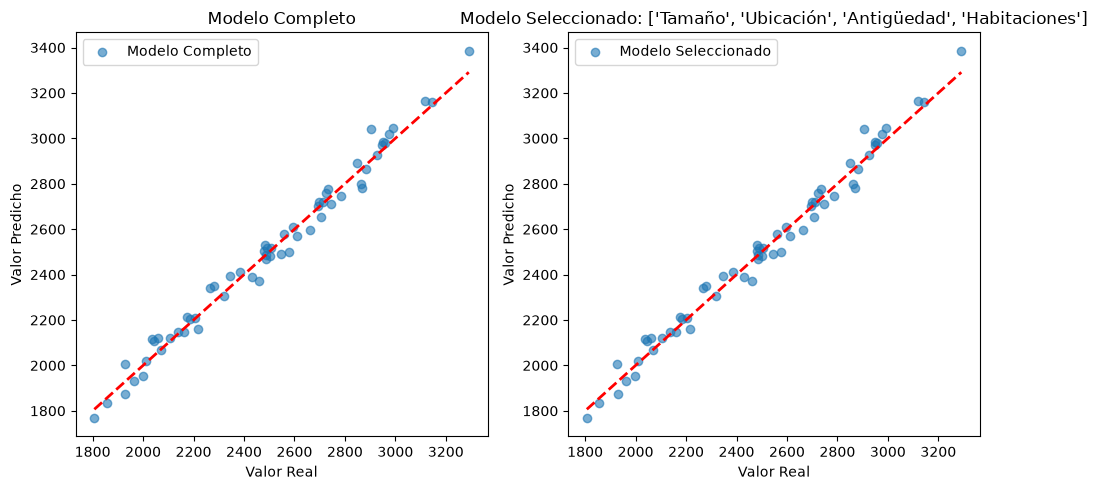

In [15]:
# Visualización del modelo seleccionado
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, label='Modelo Completo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Modelo Completo')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_sel, alpha=0.6, label='Modelo Seleccionado')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title(f'Modelo Seleccionado: {variables_seleccionadas}')
plt.legend()

plt.tight_layout()
plt.show()

## Actividad Final

Utiliza este notebook para ver qué varibles debes eliminar de la base de datos de Real Estate